# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)*

by [Urban Analytics Lab](https://ual.sg), National University of Singapore

---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


# Code_3_WVI Dataset Sampling (Hexagon & Complex IDs)

Assign spatial sampling IDs to the city-scale WVI table (same H3 logic as **Code 4** hexagon map):

| Column | Description |
|--------|-------------|
| `Hexagon_ID` | Integer 1…*N* from H3 resolution 7 cells; ordered **north→south**, then **west→east** |
| `Complex_ID` | `{Hexagon_ID}-{k}` for each distinct `(Lon, Lat)` within that hexagon (`k` = 1, 2, 3, …; same geographic order) |

**Pipeline position:** run after perception scores are merged into `data/data.csv` (Code 5 inference output → analytics table), before spatial analytics (**Code 4**) or block-CV experiments that need `Complex_ID`.

**Inputs / outputs:**
- **In:** `data/data.csv`
- **Out:** `data/data.csv` (columns inserted after `ID`), `data/metadata/code_3_hexagon_id_map.csv`, `figures/code_3_hexagon_points_overview`, `figures/code_3_hexagon_points_detail`, `data/metadata/complex_id_map.csv`

**Out (K-fold):** `data/training_features/kfold_splits/` (image-level stratified) and `kfold_splits_spatial/` (hexagon block CV).

Rescaling (`data_final_rescaled.csv`) is handled in **Code 4**, not here.



In [18]:
from pathlib import Path

import h3
import pandas as pd

H3_RESOLUTION = 7
DATA_PATH = Path("data/data.csv")
HEXAGON_MAP_PATH = Path("data/metadata/code_3_hexagon_id_map.csv")
COMPLEX_MAP_PATH = Path("data/metadata/code_3_complex_id_map.csv")


In [19]:
def build_hexagon_id_map(h3_ids):
    """Map H3 cell strings → Simple_ID (1…N), north→south then west→east."""
    unique = list(set(h3_ids))
    centers = {hid: h3.cell_to_latlng(hid) for hid in unique}
    ordered = sorted(unique, key=lambda hid: (-centers[hid][0], centers[hid][1]))
    h3_to_hex = {hid: i + 1 for i, hid in enumerate(ordered)}
    hex_map_df = pd.DataFrame(
        {
            "Simple_ID": range(1, len(ordered) + 1),
            "H3_ID": ordered,
            "Center_Lat": [centers[h][0] for h in ordered],
            "Center_Lon": [centers[h][1] for h in ordered],
        }
    )
    return h3_to_hex, hex_map_df


def assign_hexagon_and_complex_ids(df: pd.DataFrame, h3_resolution: int = H3_RESOLUTION) -> pd.DataFrame:
    """Add Hexagon_ID and Complex_ID; drop prior ID columns if re-running."""
    out = df.drop(columns=["Hexagon_ID", "Complex_ID"], errors="ignore").copy()
    h3_cells = [h3.latlng_to_cell(lat, lon, h3_resolution) for lat, lon in zip(out["Lat"], out["Lon"])]
    h3_to_hex, _ = build_hexagon_id_map(h3_cells)
    out["Hexagon_ID"] = [h3_to_hex[c] for c in h3_cells]

    chunks = []
    for hex_id, group in out.groupby("Hexagon_ID", sort=True):
        locs = (
            group[["Lon", "Lat"]]
            .drop_duplicates()
            .sort_values(by=["Lat", "Lon"], ascending=[False, True])
        )
        loc_to_complex = {
            (row.Lon, row.Lat): f"{hex_id}-{i}"
            for i, (_, row) in enumerate(locs.iterrows(), start=1)
        }
        chunks.append(
            group.assign(
                Complex_ID=[loc_to_complex[(r.Lon, r.Lat)] for _, r in group.iterrows()]
            )
        )
    out = pd.concat(chunks).sort_index()

    front = ["ID", "Hexagon_ID", "Complex_ID"]
    rest = [c for c in out.columns if c not in front]
    return out[front + rest]


In [20]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows from {DATA_PATH}")

h3_cells = [h3.latlng_to_cell(lat, lon, H3_RESOLUTION) for lat, lon in zip(df["Lat"], df["Lon"])]
_, hex_map_df = build_hexagon_id_map(h3_cells)

df_labeled = assign_hexagon_and_complex_ids(df)
df_labeled.to_csv(DATA_PATH, index=False)
hex_map_df.to_csv(HEXAGON_MAP_PATH, index=False)

complex_map = (
    df_labeled[["Complex_ID", "Hexagon_ID", "Lon", "Lat"]]
    .drop_duplicates(subset=["Complex_ID"])
    .sort_values(["Hexagon_ID", "Complex_ID"])
)
COMPLEX_MAP_PATH.parent.mkdir(parents=True, exist_ok=True)
complex_map.to_csv(COMPLEX_MAP_PATH, index=False)

print(f"Saved {DATA_PATH}")
print(f"Hexagon map → {HEXAGON_MAP_PATH} ({len(hex_map_df)} hexagons)")
print(f"Complex lookup → {COMPLEX_MAP_PATH} ({len(complex_map)} unique Lon/Lat locations)")


Loaded 12,334 rows from data/data.csv
Saved data/data.csv
Hexagon map → data/metadata/code_3_hexagon_id_map.csv (266 hexagons)
Complex lookup → data/metadata/code_3_complex_id_map.csv (1377 unique Lon/Lat locations)


In [21]:
n_hex = df_labeled["Hexagon_ID"].nunique()
n_complex = df_labeled["Complex_ID"].nunique()
per_hex = df_labeled.groupby("Hexagon_ID")["Complex_ID"].nunique()

print("Summary")
print("=" * 60)
print(f"  WVI rows:              {len(df_labeled):,}")
print(f"  Unique hexagons:       {n_hex}")
print(f"  Unique complexes:      {n_complex}  (distinct Lon/Lat)")
print(f"  Complexes per hexagon: min={per_hex.min()}, max={per_hex.max()}, median={per_hex.median():.0f}")

example_hex = int(per_hex.idxmax())
print(f"\nExample hexagon {example_hex} (most distinct locations):")
display(
    df_labeled.loc[df_labeled["Hexagon_ID"] == example_hex, ["ID", "Complex_ID", "Lon", "Lat", "Floor"]]
    .drop_duplicates(subset=["Complex_ID"])
    .head(10)
)

df_labeled.head()


Summary
  WVI rows:              12,334
  Unique hexagons:       266
  Unique complexes:      1377  (distinct Lon/Lat)
  Complexes per hexagon: min=1, max=22, median=4

Example hexagon 51 (most distinct locations):


,ID,Complex_ID,Lon,Lat,Floor
64,104111153183,51-17,114.301842,30.652490,3.0
65,104112964498,51-9,114.282965,30.657292,2.0
123,104108495683,51-7,114.281924,30.657657,3.0
374,104108256784,51-11,114.278315,30.656381,3.0
944,104107554729,51-2,114.283837,30.660617,3.0
1222,104112115019,51-8,114.278293,30.657651,3.0
1563,104109485762,51-3,114.281062,30.659592,2.0
1862,104109632757,51-14,114.283766,30.654567,3.0
2045,104106950058,51-4,114.286141,30.658854,3.0
2516,104108342803,51-6,114.294524,30.657776,3.0


,ID,Hexagon_ID,Complex_ID,Extensive,Monotonous,Oppressive,Prefer,Quiet,Vivid,Floor,...,WV_Railing,WV_Road,WV_Barrenland,WV_Buildinginterior,BD,FAR,BH,BH_SD,NDBI,NDVI
0,104108417641,245,245-3,3.948133,1.093284,1.147105,4.931551,2.610494,3.612893,3.0,...,0.116244,0.004693,0.000109,0.204845,0.113225,0.590401,13.438456,5.843095,-0.110804,0.378440
1,104110497735,52,52-5,3.697064,1.720972,0.511865,4.572644,1.783452,1.477544,3.0,...,0.112039,0.004347,0.000250,0.250782,0.140363,1.604478,25.073503,19.976318,-0.172192,0.418471
2,104110997974,245,245-3,3.542711,2.515236,0.911653,4.851386,1.595905,2.581647,3.0,...,0.111887,0.001925,0.000000,0.197726,0.113225,0.590401,13.438456,5.843095,-0.110804,0.378440
3,104110901505,99,99-9,4.387707,1.980246,0.687223,4.932484,0.600802,1.408843,3.0,...,0.164204,0.005184,0.019647,0.308308,0.254378,1.335779,14.483902,5.066555,-0.058897,0.372820
4,104113119474,196,196-4,4.629303,0.383319,0.185130,5.259705,3.079152,3.815583,3.0,...,0.160379,0.007485,0.000017,0.240501,0.265999,1.127859,11.908735,4.385089,0.001569,0.315619


## Visualization — hexagons & sampling points

Two maps (Web Mercator, EPSG:3857) with **CartoDB Positron** basemap (`contextily`), same as Code 4:

1. **Overview** — all H3 hexagons (fill = `Hexagon_ID`) and distinct **complex** locations.
2. **Detail** — zoom on the hexagon with the most complexes: boundary, WVI points, and `Complex_ID` labels.

Saved under `figures/code_3_hexagon_points_*.{png,svg}`.


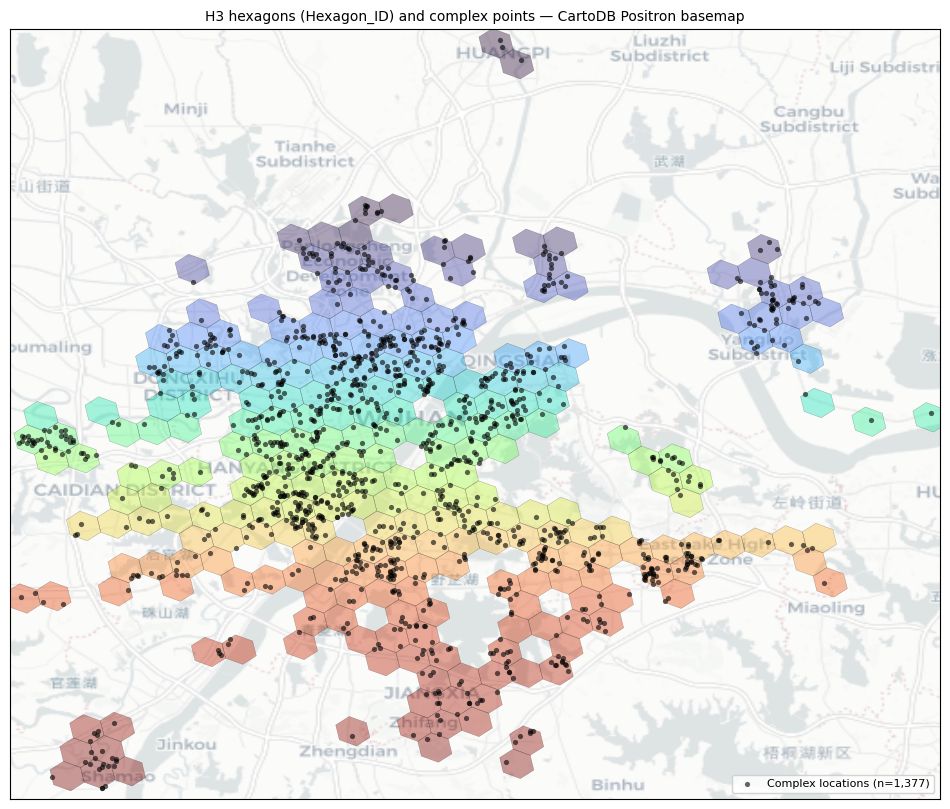

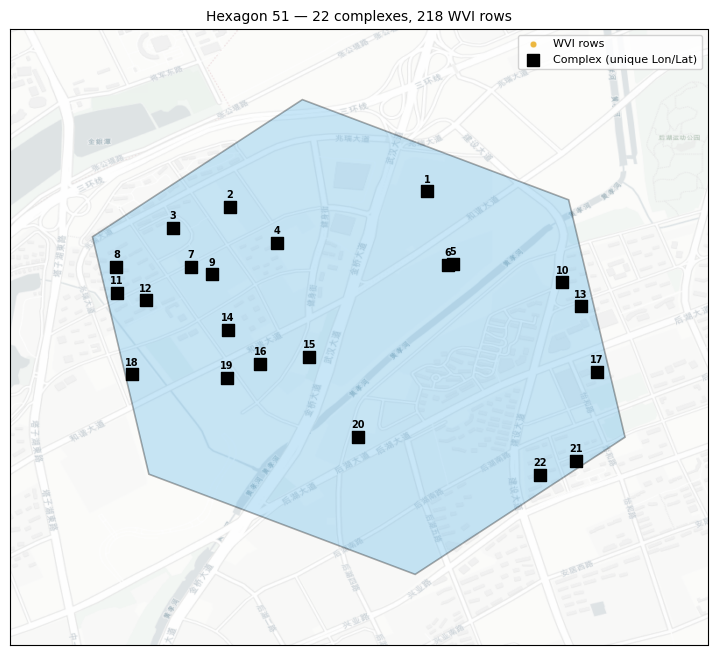

Overview → figures/code_3_hexagon_points_overview.png / .svg
Detail (hex 51) → figures/code_3_hexagon_points_detail.png / .svg


In [22]:
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
from pyproj import Transformer

TO_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
FIG_DIR = Path("figures")
BASEMAP_SOURCE = ctx.providers.CartoDB.Positron


def savefig_all(fig, basename: str, png_dpi: int = 300) -> None:
    out = Path(basename)
    out.parent.mkdir(parents=True, exist_ok=True)
    kw = {"bbox_inches": "tight", "pad_inches": 0.01}
    fig.savefig(out.with_suffix(".png"), dpi=png_dpi, **kw)
    fig.savefig(out.with_suffix(".svg"), **kw)


def h3_polygon_3857(h3_id: str):
    return [TO_3857.transform(lon, lat) for lat, lon in h3.cell_to_boundary(h3_id)]


def mercator_bounds(lons, lats, buffer_m: float = 800):
    xs, ys = TO_3857.transform(list(lons), list(lats))
    xmin, xmax = min(xs) - buffer_m, max(xs) + buffer_m
    ymin, ymax = min(ys) - buffer_m, max(ys) + buffer_m
    side = max(xmax - xmin, ymax - ymin)
    xc, yc = (xmin + xmax) / 2, (ymin + ymax) / 2
    half = side / 2
    return [xc - half, yc - half, xc + half, yc + half]


def load_basemap(bounds):
    """Fetch CartoDB Positron tiles for Web Mercator bounds [xmin, ymin, xmax, ymax]."""
    try:
        img, extent = ctx.bounds2img(*bounds, source=BASEMAP_SOURCE, ll=False)
        return img, extent, True
    except Exception as exc:
        print(f"Basemap not loaded ({exc}); plotting without background.")
        return None, None, False


def add_basemap(ax, bounds, zorder=0):
    img, extent, ok = load_basemap(bounds)
    if ok:
        ax.imshow(
            img,
            extent=extent,
            aspect="auto",
            alpha=0.75,
            interpolation="bilinear",
            resample=True,
            zorder=zorder,
        )
    return ok


hex_to_h3 = dict(zip(hex_map_df["Simple_ID"], hex_map_df["H3_ID"]))
n_hex = len(hex_to_h3)
cmap = plt.colormaps["turbo"].resampled(n_hex)

complex_xy = (
    df_labeled[["Complex_ID", "Hexagon_ID", "Lon", "Lat"]]
    .drop_duplicates(subset=["Complex_ID"])
    .copy()
)
complex_xy["x"], complex_xy["y"] = TO_3857.transform(
    complex_xy["Lon"].tolist(), complex_xy["Lat"].tolist()
)

overview_bounds = mercator_bounds(df_labeled["Lon"], df_labeled["Lat"])

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(overview_bounds[0], overview_bounds[2])
ax.set_ylim(overview_bounds[1], overview_bounds[3])
ax.set_aspect("equal", adjustable="box")
add_basemap(ax, overview_bounds)

hex_patches, hex_colors = [], []
for hex_id, h3_id in hex_to_h3.items():
    hex_patches.append(Polygon(h3_polygon_3857(h3_id), closed=True))
    hex_colors.append(cmap((hex_id - 1) / max(n_hex - 1, 1)))

pc = PatchCollection(
    hex_patches,
    facecolor=hex_colors,
    edgecolor="black",
    linewidths=0.25,
    alpha=0.4,
    zorder=2,
)
ax.add_collection(pc)

ax.scatter(
    complex_xy["x"],
    complex_xy["y"],
    s=14,
    c="black",
    alpha=0.6,
    linewidths=0,
    zorder=4,
    label=f"Complex locations (n={len(complex_xy):,})",
)
ax.legend(loc="lower right", fontsize=8, frameon=True, facecolor="white", framealpha=0.85)
ax.set_title(
    "H3 hexagons (Hexagon_ID) and complex points — CartoDB Positron basemap",
    fontsize=10,
)
ax.set_xticks([])
ax.set_yticks([])
savefig_all(fig, FIG_DIR / "code_3_hexagon_points_overview")
plt.show()

detail_hex = int(per_hex.idxmax())
detail_h3 = hex_to_h3[detail_hex]
hex_verts = h3_polygon_3857(detail_h3)

in_hex = df_labeled[df_labeled["Hexagon_ID"] == detail_hex].copy()
in_hex["x"], in_hex["y"] = TO_3857.transform(in_hex["Lon"].tolist(), in_hex["Lat"].tolist())
centroids = (
    in_hex[["Complex_ID", "x", "y"]]
    .drop_duplicates(subset=["Complex_ID"])
    .sort_values("Complex_ID")
)

pad = 450
detail_bounds = [
    min(v[0] for v in hex_verts) - pad,
    min(v[1] for v in hex_verts) - pad,
    max(v[0] for v in hex_verts) + pad,
    max(v[1] for v in hex_verts) + pad,
]

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_xlim(detail_bounds[0], detail_bounds[2])
ax.set_ylim(detail_bounds[1], detail_bounds[3])
ax.set_aspect("equal", adjustable="box")
add_basemap(ax, detail_bounds)

ax.add_patch(
    Polygon(
        hex_verts,
        closed=True,
        facecolor="#56B4E9",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.32,
        zorder=2,
    )
)
ax.scatter(
    in_hex["x"],
    in_hex["y"],
    s=22,
    c="#E69F00",
    alpha=0.75,
    edgecolors="white",
    linewidths=0.3,
    zorder=3,
    label="WVI rows",
)
ax.scatter(
    centroids["x"],
    centroids["y"],
    s=80,
    c="black",
    marker="s",
    zorder=5,
    label="Complex (unique Lon/Lat)",
)
for _, row in centroids.iterrows():
    ax.annotate(
        row["Complex_ID"].split("-")[-1],
        (row["x"], row["y"]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontweight="bold",
        zorder=6,
    )

ax.legend(loc="upper right", fontsize=8, facecolor="white", framealpha=0.85)
ax.set_title(
    f"Hexagon {detail_hex} — {len(centroids)} complexes, {len(in_hex):,} WVI rows",
    fontsize=10,
)
ax.set_xticks([])
ax.set_yticks([])
savefig_all(fig, FIG_DIR / "code_3_hexagon_points_detail")
plt.show()

print(f"Overview → {FIG_DIR / 'code_3_hexagon_points_overview'}.png / .svg")
print(f"Detail (hex {detail_hex}) → {FIG_DIR / 'code_3_hexagon_points_detail'}.png / .svg")


## Stratified K-fold (image-level)

Export frozen 5-fold splits to `data/training_features/kfold_splits/` from `TrainingFeatures_{dim}.csv` (stratified on score bins, **seed 42**, 60/20/20 train/val/test per fold). Same split logic as **Code 5**; manifests store **image IDs** so row order can change later.


In [23]:
from datetime import datetime, timezone
import json

import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
SCORE_BIN_LABELS = ["[0,1)", "[1,2)", "[2,3)", "[3,4)", "[4,5]"]
SPLIT_SEED = 42
N_FOLDS = 5
VAL_FRAC_WITHIN_TRAIN_POOL = 0.2 / 0.8  # 60/20/20 within train+val pool
TRAIN_FEATURES_DIR = Path("data/training_features")
RANDOM_SPLITS_DIR = TRAIN_FEATURES_DIR / "kfold_splits"


def score_stratum(y):
    y = np.asarray(y, dtype=float)
    return np.clip(np.floor(y).astype(int), 0, len(SCORE_BIN_LABELS) - 1)


def stratified_kfold_train_val_test_splits(y, n_folds=N_FOLDS, seed=SPLIT_SEED):
    y = np.asarray(y, dtype=float)
    strata = score_stratum(y)
    idx = np.arange(len(y))
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_i, (tr_rel, te_rel) in enumerate(skf.split(idx, strata), start=1):
        test_idx = idx[te_rel]
        trainval_idx = idx[tr_rel]
        tv_strata = strata[trainval_idx]
        rel = np.arange(len(trainval_idx))
        tr_rel_in, va_rel_in = train_test_split(
            rel,
            test_size=VAL_FRAC_WITHIN_TRAIN_POOL,
            stratify=tv_strata,
            random_state=seed + fold_i,
        )
        train_idx = trainval_idx[tr_rel_in]
        val_idx = trainval_idx[va_rel_in]
        folds.append(
            (
                sorted(train_idx.tolist()),
                sorted(val_idx.tolist()),
                sorted(test_idx.tolist()),
            )
        )
    return folds


def build_random_kfold_manifest(dim: str, df: pd.DataFrame, stratify_path: Path) -> dict:
    y = df[dim].values.astype(float)
    strata = score_stratum(y)
    folds = stratified_kfold_train_val_test_splits(y)
    samples = [
        {
            "row_index": int(i),
            "ID": str(df.iloc[i]["ID"]),
            "score": float(y[i]),
            "stratum": int(strata[i]),
            "stratum_label": SCORE_BIN_LABELS[int(strata[i])],
        }
        for i in range(len(df))
    ]
    fold_payload = []
    for fold_i, (train_idx, val_idx, test_idx) in enumerate(folds, start=1):
        fold_payload.append(
            {
                "fold": fold_i,
                "train": train_idx,
                "val": val_idx,
                "test": test_idx,
                "train_ids": [str(df.iloc[i]["ID"]) for i in train_idx],
                "val_ids": [str(df.iloc[i]["ID"]) for i in val_idx],
                "test_ids": [str(df.iloc[i]["ID"]) for i in test_idx],
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "n_test": len(test_idx),
            }
        )
    return {
        "version": 1,
        "exported_at": datetime.now(timezone.utc).isoformat(),
        "dim": dim,
        "n_folds": N_FOLDS,
        "seed": SPLIT_SEED,
        "split_mode": "random_stratified",
        "score_bins": SCORE_BIN_LABELS,
        "stratify_source": str(stratify_path.resolve()),
        "n_samples": len(df),
        "id_column": "ID",
        "note": (
            "Image-level stratified K-fold from TrainingFeatures scores. "
            "Use *_ids fields when row order changes."
        ),
        "samples": samples,
        "folds": fold_payload,
    }


def write_kfold_exports(manifest: dict, out_dir: Path) -> None:
    dim = manifest["dim"]
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / f"kfold_split_{dim}.json").write_text(
        json.dumps(manifest, indent=2), encoding="utf-8"
    )
    rows = []
    for fold in manifest["folds"]:
        for split_name, id_key in (
            ("train", "train_ids"),
            ("val", "val_ids"),
            ("test", "test_ids"),
        ):
            for img_id in fold[id_key]:
                rows.append({"dim": dim, "fold": fold["fold"], "split": split_name, "ID": img_id})
    pd.DataFrame(rows).to_csv(out_dir / f"kfold_split_{dim}.csv", index=False)


random_summary = []
for dim in PERCEPTION_DIMS:
    feat_path = TRAIN_FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    tf = pd.read_csv(feat_path)
    tf["ID"] = tf["ID"].astype(str)
    manifest = build_random_kfold_manifest(dim, tf, feat_path)
    write_kfold_exports(manifest, RANDOM_SPLITS_DIR)
    random_summary.append(
        {
            "dim": dim,
            "n_samples": manifest["n_samples"],
            "n_test_per_fold": manifest["folds"][0]["n_test"],
        }
    )

pd.DataFrame(random_summary).to_csv(RANDOM_SPLITS_DIR / "summary.csv", index=False)
print(f"Random stratified K-fold → {RANDOM_SPLITS_DIR}")
display(pd.DataFrame(random_summary))


Random stratified K-fold → data/training_features/kfold_splits


,dim,n_samples,n_test_per_fold
0,prefer,499,100
1,monotonous,499,100
2,quiet,499,100
3,extensive,499,100
4,vivid,499,100
5,oppressive,499,100


## Spatial block K-fold (no hexagon leakage)

Builds on the **image-level** splits in `kfold_splits/` (previous section), but assigns **whole `Hexagon_ID` groups** to train/val/test (stratified on per-hexagon mean score). This matches block CV for spatial generalization.

- **Random splits:** `kfold_splits/` — image-level `StratifiedKFold` (499 IDs; Code 5 default)
- **Spatial splits:** `kfold_splits_spatial/` — hexagon never in both train and test; **all 499** training IDs included. The 2 IDs missing from `data.csv` (no `Hexagon_ID`) are placed on a **random test fold** (seed 42) and in train on the other folds.


In [ ]:
from datetime import datetime, timezone
import json

import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
SCORE_BIN_LABELS = ["[0,1)", "[1,2)", "[2,3)", "[3,4)", "[4,5]"]
SPLIT_SEED = 42
N_FOLDS = 5
VAL_FRAC_WITHIN_TRAIN_POOL = 0.2 / 0.8  # 60/20/20 within train+val pool (matches random K-fold above)
GROUP_COL = "Hexagon_ID"
TRAIN_FEATURES_DIR = Path("data/training_features")
RANDOM_SPLITS_DIR = TRAIN_FEATURES_DIR / "kfold_splits"
SPATIAL_SPLITS_DIR = TRAIN_FEATURES_DIR / "kfold_splits_spatial"


def score_stratum(y):
    y = np.asarray(y, dtype=float)
    return np.clip(np.floor(y).astype(int), 0, len(SCORE_BIN_LABELS) - 1)


def spatial_block_kfold_splits(df: pd.DataFrame, y_col: str, group_col: str = GROUP_COL):
    """Assign folds by hexagon groups; stratify on mean score per hexagon."""
    tmp = df[[group_col, "ID"]].copy()
    tmp["_y"] = df[y_col].values.astype(float)
    hex_tab = tmp.groupby(group_col, as_index=False).agg(mean_score=("_y", "mean"), n=("_y", "size"))
    hex_tab["stratum"] = score_stratum(hex_tab["mean_score"].values)
    hex_ids = hex_tab[group_col].to_numpy()
    strata = hex_tab["stratum"].to_numpy()
    idx_by_hex = {k: v.tolist() for k, v in df.groupby(group_col).indices.items()}

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SPLIT_SEED)
    folds = []
    for fold_i, (tr_hex_rel, te_hex_rel) in enumerate(skf.split(hex_ids, strata), start=1):
        test_hex = set(hex_ids[te_hex_rel])
        trainval_hex = hex_ids[tr_hex_rel]
        tv_strata = hex_tab.loc[hex_tab[group_col].isin(trainval_hex), "stratum"].values
        tr_h, va_h = train_test_split(
            trainval_hex,
            test_size=VAL_FRAC_WITHIN_TRAIN_POOL,
            stratify=tv_strata,
            random_state=SPLIT_SEED + fold_i,
        )
        train_hex, val_hex = set(tr_h), set(va_h)
        train_idx, val_idx, test_idx = [], [], []
        for h in train_hex:
            train_idx.extend(idx_by_hex[h])
        for h in val_hex:
            val_idx.extend(idx_by_hex[h])
        for h in test_hex:
            test_idx.extend(idx_by_hex[h])
        folds.append((sorted(train_idx), sorted(val_idx), sorted(test_idx)))
    return folds, hex_tab


def hex_ids_at(df: pd.DataFrame, indices) -> set:
    if not len(indices):
        return set()
    vals = df.iloc[list(indices)][GROUP_COL].dropna()
    return {int(v) for v in vals}


def assign_orphans_to_folds(
    merged: pd.DataFrame,
    folds: list,
    orphan_idx: list,
    y_col: str,
    seed_offset: int = 0,
) -> list:
    """IDs without Hexagon_ID: one random test fold each; train pool on other folds."""
    if not orphan_idx:
        return folds
    rng = np.random.default_rng(SPLIT_SEED + seed_offset)
    orphans = sorted(orphan_idx, key=lambda i: str(merged.iloc[i]["ID"]))
    strata = score_stratum(merged.loc[orphans, y_col].values.astype(float))
    if len(orphans) >= N_FOLDS:
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SPLIT_SEED + seed_offset)
        test_fold = {}
        for fold_i, (_, te_rel) in enumerate(skf.split(np.zeros(len(orphans)), strata)):
            for j in te_rel:
                test_fold[orphans[j]] = fold_i
    else:
        order = rng.permutation(len(orphans))
        test_fold = {orphans[order[i]]: i % N_FOLDS for i in range(len(orphans))}
    out = []
    for fold_i, (tr, va, te) in enumerate(folds):
        tr, va, te = list(tr), list(va), list(te)
        for o in orphans:
            if test_fold[o] == fold_i:
                te.append(o)
            else:
                tr.append(o)
        out.append((sorted(tr), sorted(va), sorted(te)))
    return out


def build_spatial_manifest(dim: str, df: pd.DataFrame, folds, stratify_path: Path) -> dict:
    y = df[dim].values.astype(float)
    strata = score_stratum(y)
    samples = []
    for i in range(len(df)):
        hex_val = df.iloc[i][GROUP_COL]
        samples.append(
            {
                "row_index": int(i),
                "ID": str(df.iloc[i]["ID"]),
                GROUP_COL: int(hex_val) if pd.notna(hex_val) else None,
                "score": float(y[i]),
                "stratum": int(strata[i]),
                "stratum_label": SCORE_BIN_LABELS[int(strata[i])],
            }
        )
    fold_payload = []
    for fold_i, (train_idx, val_idx, test_idx) in enumerate(folds, start=1):
        fold_payload.append(
            {
                "fold": fold_i,
                "train": train_idx,
                "val": val_idx,
                "test": test_idx,
                "train_ids": [str(df.iloc[i]["ID"]) for i in train_idx],
                "val_ids": [str(df.iloc[i]["ID"]) for i in val_idx],
                "test_ids": [str(df.iloc[i]["ID"]) for i in test_idx],
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "n_test": len(test_idx),
                "n_train_hex": len(hex_ids_at(df, train_idx)),
                "n_val_hex": len(hex_ids_at(df, val_idx)),
                "n_test_hex": len(hex_ids_at(df, test_idx)),
            }
        )
    return {
        "version": 1,
        "exported_at": datetime.now(timezone.utc).isoformat(),
        "dim": dim,
        "n_folds": N_FOLDS,
        "seed": SPLIT_SEED,
        "split_mode": "spatial_block",
        "group_column": GROUP_COL,
        "score_bins": SCORE_BIN_LABELS,
        "stratify_source": str(stratify_path.resolve()),
        "n_samples": len(df),
        "id_column": "ID",
        "note": (
            "Hexagon-level block CV; training IDs without Hexagon_ID get a "
            "random image-level test fold (same seed). Layout matches kfold_splits/."
        ),
        "samples": samples,
        "folds": fold_payload,
    }


def write_kfold_exports(manifest: dict, out_dir: Path) -> None:
    dim = manifest["dim"]
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / f"kfold_split_{dim}.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    rows = []
    for fold in manifest["folds"]:
        for split_name, id_key in (
            ("train", "train_ids"),
            ("val", "val_ids"),
            ("test", "test_ids"),
        ):
            for img_id in fold[id_key]:
                rows.append({"dim": dim, "fold": fold["fold"], "split": split_name, "ID": img_id})
    pd.DataFrame(rows).to_csv(out_dir / f"kfold_split_{dim}.csv", index=False)


def hex_overlap_from_ids(train_ids, test_ids, id_to_hex: dict) -> int:
    train_hex = {id_to_hex[i] for i in train_ids if i in id_to_hex}
    test_hex = {id_to_hex[i] for i in test_ids if i in id_to_hex}
    return len(train_hex & test_hex)


def hex_train_test_overlap(train_idx, test_idx, df: pd.DataFrame) -> int:
    train_hex = hex_ids_at(df, train_idx)
    test_hex = hex_ids_at(df, test_idx)
    return len(train_hex & test_hex)


# Join training features with Hexagon_ID from labelled city table
_city_spatial = df_labeled[["ID", GROUP_COL, "Complex_ID"]].copy()
_city_spatial["ID"] = _city_spatial["ID"].astype(str)

spatial_summary = []
leakage_compare = []

for dim in PERCEPTION_DIMS:
    feat_path = TRAIN_FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    tf = pd.read_csv(feat_path)
    tf["ID"] = tf["ID"].astype(str)
    merged = tf.merge(_city_spatial, on="ID", how="left").reset_index(drop=True)
    orphan_idx = merged.index[merged[GROUP_COL].isna()].tolist()
    hex_row_idx = merged.index[merged[GROUP_COL].notna()].tolist()
    if orphan_idx:
        print(
            f"[{dim}] {len(orphan_idx)} IDs without {GROUP_COL} → random test-fold assignment: "
            f"{merged.loc[orphan_idx, 'ID'].tolist()}"
        )

    df_hex = merged.loc[hex_row_idx].copy()
    df_hex[GROUP_COL] = df_hex[GROUP_COL].astype(int)
    df_hex = df_hex.reset_index(drop=True)
    folds_hex, hex_tab = spatial_block_kfold_splits(df_hex, dim)
    folds_hex_global = [
        (
            sorted(hex_row_idx[i] for i in tr),
            sorted(hex_row_idx[i] for i in va),
            sorted(hex_row_idx[i] for i in te),
        )
        for tr, va, te in folds_hex
    ]
    folds = assign_orphans_to_folds(
        merged, folds_hex_global, orphan_idx, dim, seed_offset=PERCEPTION_DIMS.index(dim)
    )
    manifest = build_spatial_manifest(dim, merged, folds, feat_path)
    write_kfold_exports(manifest, SPATIAL_SPLITS_DIR)
    spatial_summary.append(
        {
            "dim": dim,
            "n_samples": manifest["n_samples"],
            "n_hexagons": int(merged[GROUP_COL].dropna().nunique()),
            "n_orphans_random": len(orphan_idx),
            "n_test_per_fold": manifest["folds"][0]["n_test"],
            "n_test_hex_per_fold": manifest["folds"][0]["n_test_hex"],
        }
    )

    rand_json = RANDOM_SPLITS_DIR / f"kfold_split_{dim}.json"
    if rand_json.exists():
        rm = json.loads(rand_json.read_text(encoding="utf-8"))
        has_hex = merged[GROUP_COL].notna()
        id_to_hex = dict(
            zip(merged.loc[has_hex, "ID"], merged.loc[has_hex, GROUP_COL].astype(int))
        )
        for fold in rm["folds"]:
            leakage_compare.append(
                {
                    "dim": dim,
                    "fold": fold["fold"],
                    "split_type": "random_stratified",
                    "n_overlap_hex": hex_overlap_from_ids(
                        fold["train_ids"], fold["test_ids"], id_to_hex
                    ),
                }
            )
    for fold_i, (tr, va, te) in enumerate(folds, start=1):
        leakage_compare.append(
            {
                "dim": dim,
                "fold": fold_i,
                "split_type": "spatial_block",
                "n_overlap_hex": hex_train_test_overlap(tr, te, merged),
            }
        )

pd.DataFrame(spatial_summary).to_csv(SPATIAL_SPLITS_DIR / "summary.csv", index=False)
pd.DataFrame(leakage_compare).to_csv(SPATIAL_SPLITS_DIR / "spatial_vs_random_leakage.csv", index=False)

print(f"Spatial block K-fold → {SPATIAL_SPLITS_DIR}")
display(pd.DataFrame(spatial_summary))
display(pd.DataFrame(leakage_compare).pivot_table(
    index=["dim", "fold"], columns="split_type", values="n_overlap_hex", aggfunc="first"
))


